In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset movies 

In [43]:
movies = pd.read_csv("../data/raw/movies.csv")

In [44]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [45]:
movies.shape

(9742, 3)

In [46]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB


In [47]:
movies.describe(include="all")

,movieId,title,genres
count,9742.000000,9742,9742
unique,NaN,9737,951
top,NaN,Emma (1996),Drama
freq,NaN,2,1053
mean,42200.353623,NaN,NaN
std,52160.494854,NaN,NaN
min,1.000000,NaN,NaN
25%,3248.250000,NaN,NaN
50%,7300.000000,NaN,NaN
75%,76232.000000,NaN,NaN


In [48]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [49]:
movies.duplicated().sum()

np.int64(0)

In [50]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [51]:
duplicated_titles = movies[movies["title"].duplicated(keep=False)].sort_values("title")
duplicated_titles

,movieId,title,genres
4169,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller
9106,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller
650,838,Emma (1996),Comedy|Drama|Romance
5601,26958,Emma (1996),Romance
5854,32600,Eros (2004),Drama
9135,147002,Eros (2004),Drama|Romance
2141,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller
9468,168358,Saturn 3 (1980),Sci-Fi|Thriller
5931,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller
6932,64997,War of the Worlds (2005),Action|Sci-Fi


In [52]:
# See the different genres and how many times they appear
genres = movies["genres"].str.split("|").explode()

genres.value_counts()

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

In [53]:
# Extract the year from the title
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)")

movies["year"] = pd.to_numeric(movies["year"], errors="coerce")

movies["year"].value_counts().sort_index()

year
1902.0      1
1903.0      1
1908.0      1
1915.0      1
1916.0      4
         ... 
2014.0    278
2015.0    274
2016.0    218
2017.0    147
2018.0     41
Name: count, Length: 106, dtype: int64

In [54]:
# Create a clean title without the release year
movies["clean_title"] = movies["title"].str.replace(r"\s*\(\d{4}\)", "", regex=True)

In [55]:
# Convert genres into a list
movies["genres_list"] = movies["genres"].str.split("|")

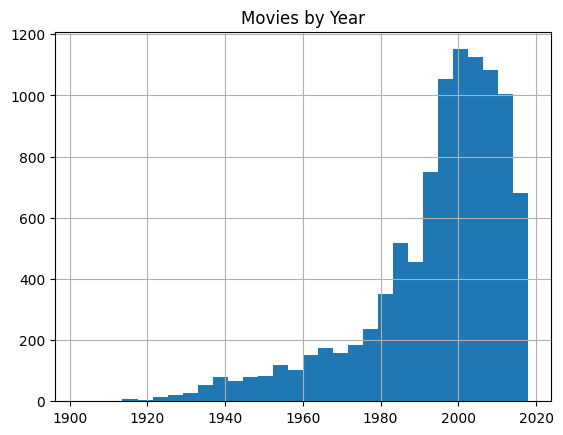

In [56]:
movies["year"].hist(bins=30)

plt.title("Movies by Year")
plt.show()

In [57]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   movieId      9742 non-null   int64  
 1   title        9742 non-null   str    
 2   genres       9742 non-null   str    
 3   year         9729 non-null   float64
 4   clean_title  9742 non-null   str    
 5   genres_list  9742 non-null   object 
dtypes: float64(1), int64(1), object(1), str(3)
memory usage: 1.0+ MB


In [58]:
# Create the processed movies dataset in the processed directory
movies.to_csv("../data/processed/movies_clean.csv", index=False)

## Observations (movies)

- The dataset contains 9,742 movies
- There are no missing values and no duplicated rows
- Some movies appear multiple times with different movieIds, they were preserved as they represent a little part of the total and there are ratings linked to them
- The movie release year was extracted from the title and stored in a new `year` column
- There are 13 movies title which contain no year. Since they represent a very small percentage of the dataset, they have been kept and their year is left as missing (NaN)
- There are 34 movies which don't have genres

# Dataset ratings 

In [59]:
ratings = pd.read_csv("../data/raw/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [60]:
ratings.shape

(100836, 4)

In [61]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [62]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [63]:
ratings["userId"].nunique()

610

In [64]:
ratings["movieId"].nunique()

9724

In [65]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [66]:
ratings.duplicated().sum()

np.int64(0)

In [67]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [68]:
ratings["rating"].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

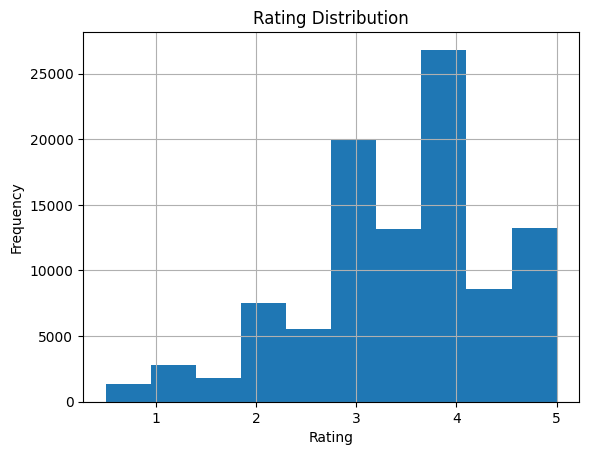

In [69]:
ratings["rating"].hist(bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [70]:
user_activity = ratings.groupby("userId").agg(
    nRatings=("rating", "count"),
    avgRating=("rating", "mean")
)

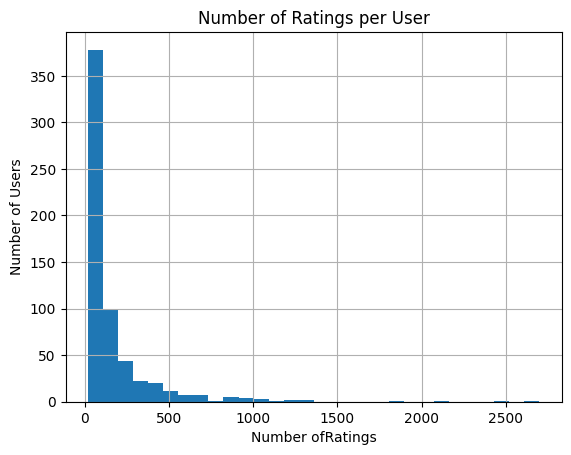

In [71]:
user_activity["nRatings"].hist(bins=30)

plt.title("Number of Ratings per User")
plt.xlabel("Number ofRatings")
plt.ylabel("Number of Users")
plt.show()

In [72]:
movie_popularity = ratings.groupby("movieId").agg(
    nRatings = ("movieId", "count"),
    avgRating = ("rating", "mean")
)

movie_popularity.head()

,nRatings,avgRating
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429


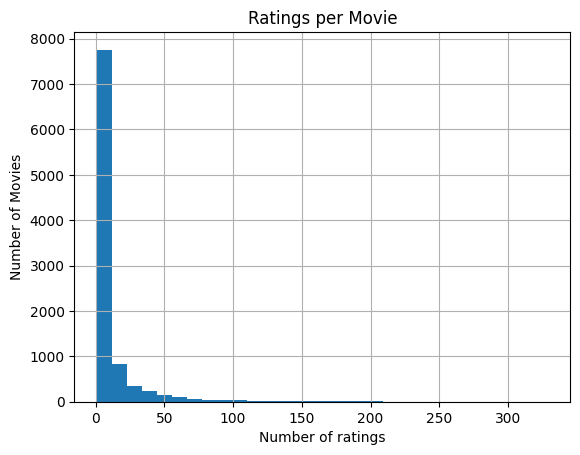

In [73]:
movie_popularity["nRatings"].hist(bins=30)

plt.title("Ratings per Movie")
plt.xlabel("Number of ratings")
plt.ylabel("Number of Movies")
plt.show()

In [74]:
ratings["timestamp"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

ratings["timestamp"].head()

0   2000-07-30 18:45:03
1   2000-07-30 18:20:47
2   2000-07-30 18:37:04
3   2000-07-30 19:03:35
4   2000-07-30 18:48:51
Name: timestamp, dtype: datetime64[s]

In [75]:
ratings["timestamp"].min()

Timestamp('1996-03-29 18:36:55')

In [76]:
ratings["timestamp"].max()

Timestamp('2018-09-24 14:27:30')

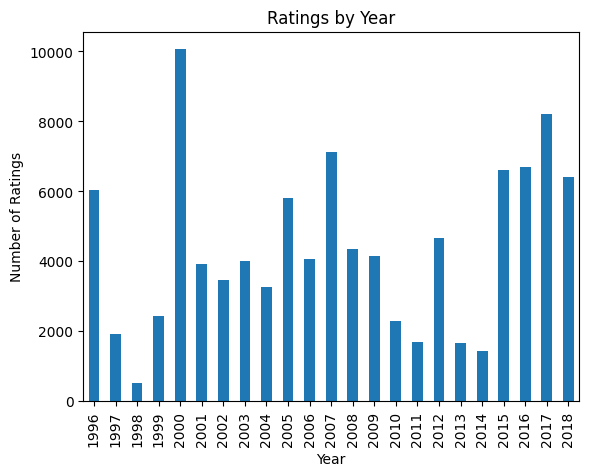

In [77]:
ratings["timestamp"].dt.year.value_counts().sort_index().plot(kind="bar")

plt.title("Ratings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

In [78]:
# Create the processed ratings dataset
ratings.to_csv("../data/processed/ratings_clean.csv", index=False)

## Observations (ratings)
- The dataset contains 100,836 ratings of 9,724 movies from 610 users
- No missing values were found.
- The dataset doesn't have any duplicated rows 
- Ratings range from 0.5 to 5.0.
- Most ratings are concentrated between 3.0 and 5.0, which indicates a positive rating bias
- User activity is highly uneven, with some users rating significantly more movies than others.
- Some users consistently give higher ratings in average than others, suggesting differences in rating behavior. This may introduce bias in collaborative filtering models and could require normalizing the ratings
- Movie popularity is also uneven, with a small number of movies receiving many ratings.
- Some movies receive substantially more ratings than others, indicating an uneven popularity distribution. This popularity bias may affect recommendation quality, as highly rated movies have more available information than less frequently rated movies.
- The ratings date extends from 1996 to 2018